# BBF ± FHR on Krull — Atari-100k results

**Branch `atari/atari-100k-bbf` · 2026-08-22 · single GB10 GPU · seed 0 (tuning phase)**

This notebook presents the head-to-head comparison of the in-repo **BBF recipe**
(Schwarzer et al. 2023, ported from the official `BBF.gin`, RR = 2 variant) trained with
its plain TD objective versus the same recipe with the **FHR recurrence regulariser**
(λ = 0.5, order r = 4) added to the loss — on Krull under the corrected Atari-100k
protocol.

**The recipe** — Impala-CNN ×4 encoder (15 conv layers, per-sample feature
renormalisation), IQN-8 dueling head (2048 hidden), AdamW (lr 1e-4, wd 0.1 bias-exempt),
EMA target (τ = 0.005/gradient step) with target-network action selection, n-step 10→3
and γ 0.97→0.997 annealed over 10k gradient steps after **each shrink-and-perturb
reset** (every 40k gradient steps, none after 130k), DrQ augmentation (shift ±4 +
intensity 0.05), linear ε → 0 over 2001 steps, replay ratio 2.

**Documented deviations from published BBF**: IQN-8 head instead of C51-51, uniform
episodic replay instead of PER, and **no SPR auxiliary loss** — deliberately, because the
FHR penalty is the auxiliary under test here.

**Protocol** (see `src/analysis/atari100k.py`): 100,000 agent-env interactions,
frameskip 4, deterministic ALE (no sticky actions), minimal action set, sign-clipped
training rewards. Training uses **episodic-life** (a life loss ends the agent's episode
and cuts the value bootstrap, while the game continues to real game-over — the
Dopamine/DeepMind convention every published baseline trains under). Final evaluation is
described in §3.

In [1]:
import csv, glob, json, pathlib, sys
import numpy as np
import matplotlib.pyplot as plt

HERE = pathlib.Path.cwd()                      # experiments/atari/dqn_krull
SRC = HERE.parents[2] / "src"                  # repo library code
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
from analysis.atari100k import REFERENCE, hns   # verified reference table

plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "legend.frameon": False,
})
ARMS = {   # display name -> (run dir, colour)
    "BBF (TD only)": (
        "cached/runs/dqn_krull_fhrdqn100k_baseline_seed0_20260821-225253", "tab:blue"),
    "BBF + FHR (λ=0.5, r=4)": (
        "cached/runs/dqn_krull_fhrdqn100k_exp1_seed0_20260822-032428", "tab:orange"),
}

def load_rewards(run):
    a = np.genfromtxt(HERE / run / "rewards.csv", delimiter=",", names=True)
    return a["reward"], a["steps"].astype(int)

def load_diag(run):
    return np.genfromtxt(HERE / run / "train_diagnostics.csv", delimiter=",",
                         names=True)

def load_eval(run):
    scores = np.genfromtxt(HERE / run / "eval_scores.csv", delimiter=",",
                           skip_header=1)[:, 1]
    summary = json.load(open(HERE / run / "eval_summary.json"))
    return scores, summary

def reset_positions(diag):
    "env-step index of each shrink-and-perturb reset (diagnostics are 1 row/env step)"
    r = diag["resets"]
    return np.flatnonzero(np.diff(r) > 0) + 1

def smooth(x, k):
    if len(x) < k:
        return x
    return np.convolve(x, np.ones(k) / k, mode="valid")

DATA = {name: {"rew": load_rewards(run), "diag": load_diag(run),
               "eval": load_eval(run), "dir": run, "colour": col}
        for name, (run, col) in ARMS.items()}
for name, d in DATA.items():
    s, m = d["eval"]
    print(f"{name:24s} eval mean {m['mean']:7.1f}  median {m['median']:7.1f}  "
          f"episodes {m['episodes']}  (train life-segments: {len(d['rew'][0])})")

BBF (TD only)            eval mean  3282.8  median  2570.0  episodes 32  (train life-segments: 207)
BBF + FHR (λ=0.5, r=4)   eval mean  3853.4  median  3990.0  episodes 32  (train life-segments: 223)


## 1 · Training learning curves — the reward the agent *saw*

Each point is one **agent episode = one life segment** (episodic-life protocol), plotted
against cumulative environment steps. Two readings of "training reward":

* The agent **optimises sign-clipped rewards** (every score event → +1) — the
  "regularised" reward of the TD objective. Per protocol, the logger records the **raw
  game score** of each life segment (the sign-clip wrapper passes the raw value through
  `info["raw_reward"]`), so curves stay comparable across games and methods; the clipped
  return is a monotone compression of the same events.
* Because episodes are single lives here, these values are roughly **⅓ of a full game
  score** — §2 reconstructs the full-game view.

Vertical dashed lines mark **shrink-and-perturb resets** — performance is *expected* to
dip and re-anneal after each one.

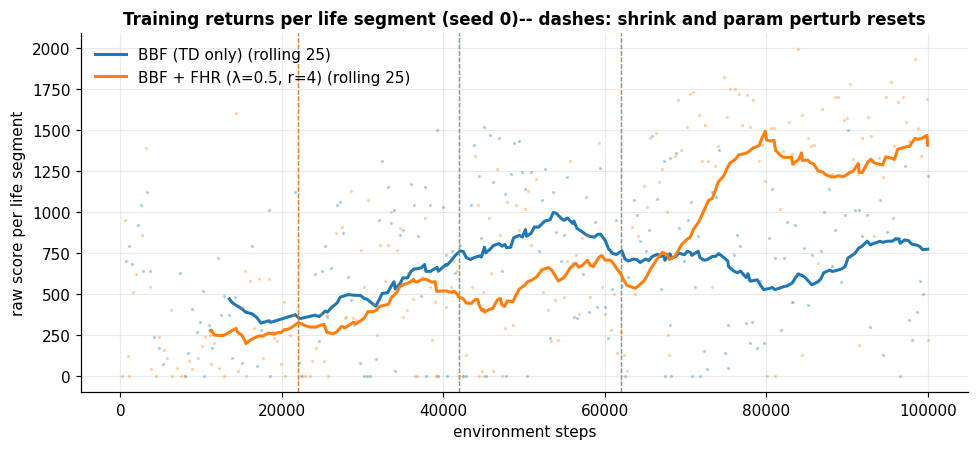

In [2]:
fig, ax = plt.subplots(figsize=(9, 4.2))
K = 25
for name, d in DATA.items():
    rew, steps = d["rew"]
    x = np.cumsum(steps)
    ax.plot(x, rew, ".", ms=2.5, alpha=0.25, color=d["colour"])
    xs = x[K - 1:]
    ax.plot(xs, smooth(rew, K), lw=2, color=d["colour"], label=f"{name} (rolling {K})")
    for rp in reset_positions(d["diag"]):
        ax.axvline(rp + 2000, color=d["colour"], ls="--", lw=0.8, alpha=0.5)
ax.set(xlabel="environment steps", ylabel="raw score per life segment",
       title="Training returns per life segment (seed 0)-- dashes: shrink and param perturb resets")
ax.legend(loc="upper left")
plt.tight_layout()

## 2 · Reconstructed *true* (full-game) reward over training

Krull always starts with 3 lives, so consecutive life segments are grouped in threes to
approximate the **full-game score** the same behaviour would have produced. Two known
imperfections, stated for honesty: the 100k-step cap truncates the final game, and the
two mid-run analysis ticks (episodes 0/40/…/200-spaced) roll the training env to
termination, which can desynchronise one grouping each. The trend, not the exact values,
is the point — the final-policy evaluation in §3 is the rigorous full-game measurement.

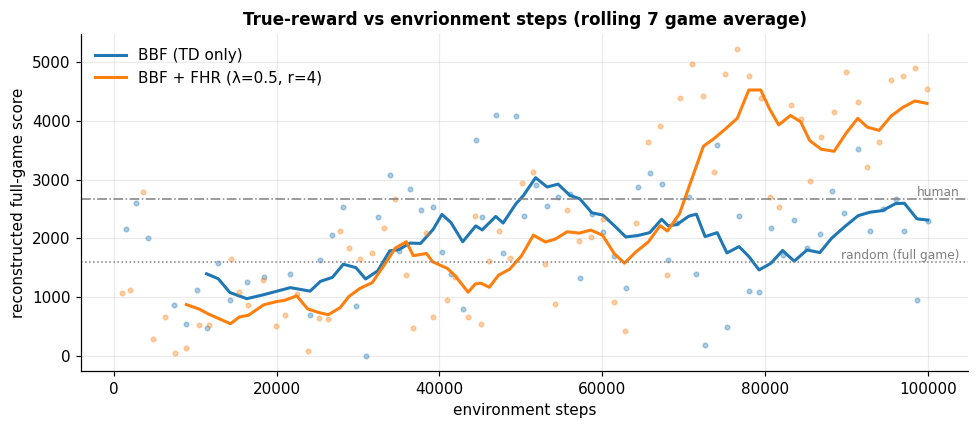

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
for name, d in DATA.items():
    rew, steps = d["rew"]
    n = len(rew) // 3
    games = rew[:n * 3].reshape(n, 3).sum(axis=1)
    gx = np.cumsum(steps)[:n * 3].reshape(n, 3)[:, -1]
    ax.plot(gx, games, "o", ms=3, alpha=0.35, color=d["colour"])
    if n >= 7:
        ax.plot(gx[6:], smooth(games, 7), lw=2, color=d["colour"],
                label=f"{name}")
for m, ls, lab in ((1598.0, ":", "random (full game)"), (2665.5, "-.", "human")):
    ax.axhline(m, color="gray", ls=ls, lw=1)
    ax.annotate(lab, (0.99, m), xycoords=("axes fraction", "data"),
                ha="right", va="bottom", fontsize=8, color="gray")
ax.set(xlabel="environment steps", ylabel="reconstructed full-game score",
       title="True-reward vs envrionment steps (rolling 7 game average)")
ax.legend(loc="upper left")
plt.tight_layout()

## 3 · Final evaluation — protocol and results

**How the final numbers are produced** (`evaluate_policy_atari`, `src/training.py`; call
site `experiments/src/run_fhrdqn_atari100k.py::run_one`):

* After the 100k-step budget, the trained agent plays **32 evaluation episodes** on a
  **fresh env** built with `terminal_on_life_loss = False` **and** `episodic_life =
  False` — i.e. every evaluation episode is a **complete game across all lives**, ending
  only at real game-over (or the benchmark's 108k-frame cap). This matches how every
  published Atari-100k number is scored.
* Action selection is **ε-greedy with ε = 0.001** (the DER/DrQ/SPR convention); for the
  BBF agents, greedy actions come from the EMA target network (`target_action_selection`,
  as in SR-SPR/BBF). Resets are seeded `1000 + episode`, so both arms score the *same*
  32 start conditions — a paired comparison.
* Scores are **raw, unclipped game scores** via `info["raw_reward"]`; nothing from
  evaluation enters the replay buffer. Per run they land in `eval_scores.csv` /
  `eval_summary.json`.

Left: means with 95 % CI. Right: the full score distributions — the FHR arm is not just
better on average, it is dramatically **more consistent**.

BBF (TD only)            mean  3282.8  median  2570.0  std  1886.8  min    550  max   7900  HNS 1.578
BBF + FHR (λ=0.5, r=4)   mean  3853.4  median  3990.0  std   826.2  min   2280  max   5100  HNS 2.113


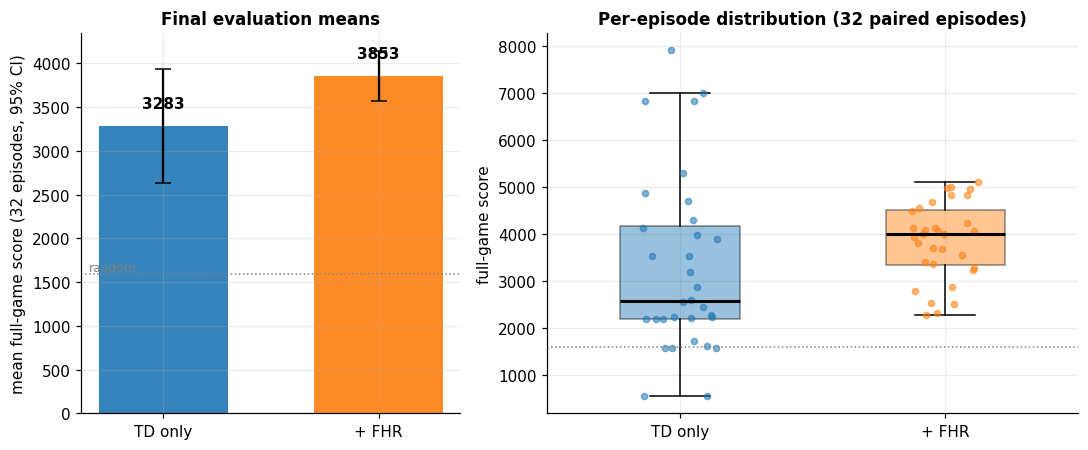

In [4]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 4.2), width_ratios=[1, 1.4])
names = list(DATA)
scores = [DATA[n]["eval"][0] for n in names]
cols = [DATA[n]["colour"] for n in names]
means = [s.mean() for s in scores]
ci = [1.96 * s.std(ddof=1) / np.sqrt(len(s)) for s in scores]
bars = a1.bar(range(2), means, yerr=ci, capsize=5, color=cols, width=0.6, alpha=0.9)
for i, (m, s) in enumerate(zip(means, scores)):
    a1.annotate(f"{m:.0f}", (i, m), ha="center", va="bottom", fontweight="bold",
                xytext=(0, 10), textcoords="offset points")
a1.axhline(1598.0, color="gray", ls=":", lw=1)
a1.annotate("random", (0.02, 1598), xycoords=("axes fraction", "data"),
            fontsize=8, color="gray", va="bottom")
a1.set(xticks=range(2), xticklabels=["TD only", "+ FHR"],
       ylabel="mean full-game score (32 episodes, 95% CI)",
       title="Final evaluation means")
bp = a2.boxplot(scores, positions=range(2), widths=0.45, patch_artist=True,
                medianprops=dict(color="black", lw=2), showfliers=False)
for patch, c in zip(bp["boxes"], cols):
    patch.set(facecolor=c, alpha=0.45)
rng = np.random.default_rng(0)
for i, (s, c) in enumerate(zip(scores, cols)):
    a2.plot(i + rng.uniform(-0.14, 0.14, len(s)), s, "o", ms=4, alpha=0.55, color=c)
a2.axhline(1598.0, color="gray", ls=":", lw=1)
a2.set(xticks=range(2), xticklabels=["TD only", "+ FHR"],
       ylabel="full-game score", title="Per-episode distribution (32 paired episodes)")
for n, s in zip(names, scores):
    print(f"{n:24s} mean {s.mean():7.1f}  median {np.median(s):7.1f}  "
          f"std {s.std(ddof=1):7.1f}  min {s.min():6.0f}  max {s.max():6.0f}  "
          f"HNS {hns(float(s.mean()), 'Krull'):.3f}")
plt.tight_layout()

## 4 · Against the published Atari-100k methods on Krull

All comparison values were re-verified digit-for-digit against the primary sources on
2026-08-22: the **EfficientZero paper** (Ye et al. 2021, arXiv:2111.00210, Table 1 —
SimPLe/OTRainbow/CURL/DrQ/SPR/MuZero/EfficientZero, random and human) and the **BBF
paper** (Schwarzer et al. 2023, arXiv:2305.19452, Table A.1 — DER, DrQ(ε), SR-SPR, BBF,
IRIS). Caveats for fairness: published numbers average many seeds (BBF: 50; most others
30–100) versus our single seed; published **BBF is the RR = 8 configuration *with* SPR
and prioritized replay**, whereas our port is RR = 2, no SPR/PER — the like-for-like
anchors for this port are DrQ/SPR-class methods.

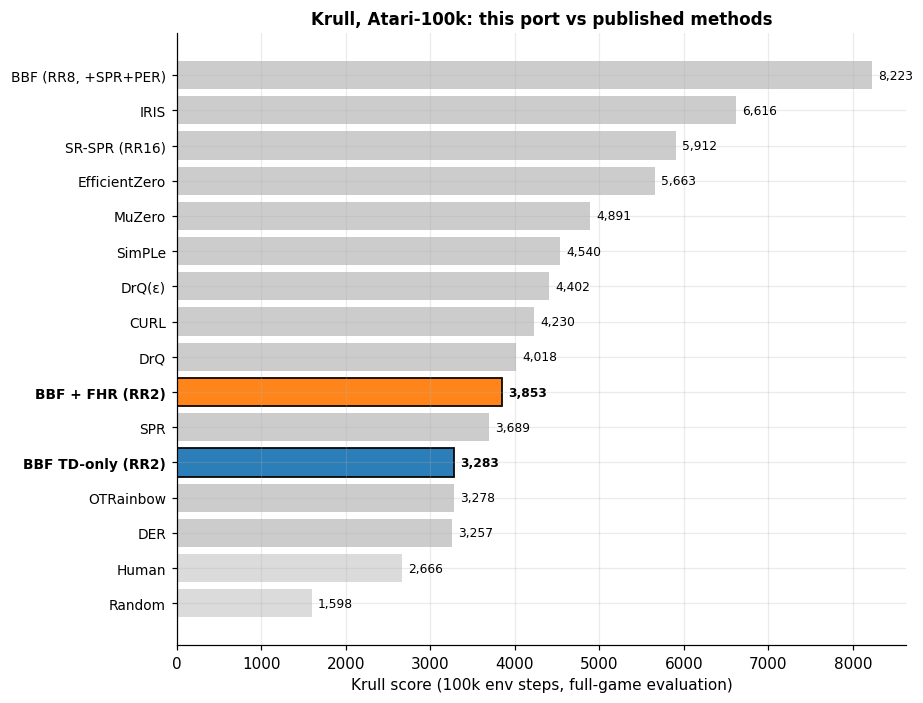

In [5]:
published = [   # (label, score, source)
    ("Random",            1598.0, "EZ Table 1"),
    ("Human",             2665.5, "EZ Table 1"),
    ("DER",               3256.9, "BBF Table A.1"),
    ("OTRainbow",         3277.9, "EZ Table 1"),
    ("SPR",               3688.9, "EZ Table 1"),
    ("DrQ",               4018.1, "EZ Table 1"),
    ("CURL",              4229.6, "EZ Table 1"),
    ("DrQ(ε)",            4402.1, "BBF Table A.1"),
    ("SimPLe",            4539.9, "EZ Table 1"),
    ("EfficientZero",     5663.3, "EZ Table 1"),
    ("SR-SPR (RR16)",     5911.8, "BBF Table A.1"),
    ("IRIS",              6616.4, "BBF Table A.1"),
    ("MuZero",            4890.8, "EZ Table 1"),
    ("BBF (RR8, +SPR+PER)", 8223.4, "BBF Table A.1"),
]
ours = [("BBF TD-only (RR2)", DATA["BBF (TD only)"]["eval"][1]["mean"]),
        ("BBF + FHR (RR2)",
         DATA["BBF + FHR (λ=0.5, r=4)"]["eval"][1]["mean"])]
rows = sorted(published + [(l, s, "ours") for l, s in ours], key=lambda r: r[1])
fig, ax = plt.subplots(figsize=(8.5, 6.5))
ypos = range(len(rows))
for y, (label, scr, src) in zip(ypos, rows):
    is_ours = src == "ours"
    is_anchor = label in ("Random", "Human")
    col = ("tab:orange" if "FHR" in label else "tab:blue") if is_ours \
        else ("lightgray" if is_anchor else "silver")
    ax.barh(y, scr, color=col, alpha=0.95 if is_ours else 0.8,
            edgecolor="black" if is_ours else "none", lw=1.2)
    ax.annotate(f"{scr:,.0f}", (scr, y), va="center", ha="left",
                xytext=(4, 0), textcoords="offset points",
                fontsize=8, fontweight="bold" if is_ours else "normal")
ax.set_yticks(list(ypos))
ax.set_yticklabels([r[0] for r in rows],
                   fontsize=9)
for tick, (label, _, src) in zip(ax.get_yticklabels(), rows):
    if src == "ours":
        tick.set_fontweight("bold")
ax.set(xlabel="Krull score (100k env steps, full-game evaluation)",
       title="Krull, Atari-100k: this port vs published methods")
plt.tight_layout()

## 5 · The objective being optimised — TD loss, regulariser, total

Both arms minimise the IQN quantile-Huber **TD loss**; the FHR arm adds
**λ · Huber(recurrence residual)** after a 10k-gradient-step hard warm-up. The residual
for a sampled transition $(s_t,a_t)$ with same-episode predecessors is

$$\rho_t \;=\; Q_\theta(s_t,a_t)\;-\;\textstyle\sum_{j=1}^{r} c_j\,Q_\theta(s_{t-j},a_{t-j}),$$

with the lag coefficients $c \in \mathbb{R}^4$ **learned jointly** by the same optimiser
(own parameter group: no weight decay, own learning rate, excluded from target sync and
gradient clipping — and they deliberately **survive shrink-and-perturb resets** while the
Q-network under them is re-initialised). Curves are rolling means over 500 gradient-step
diagnostics rows; resets marked as dashed lines.

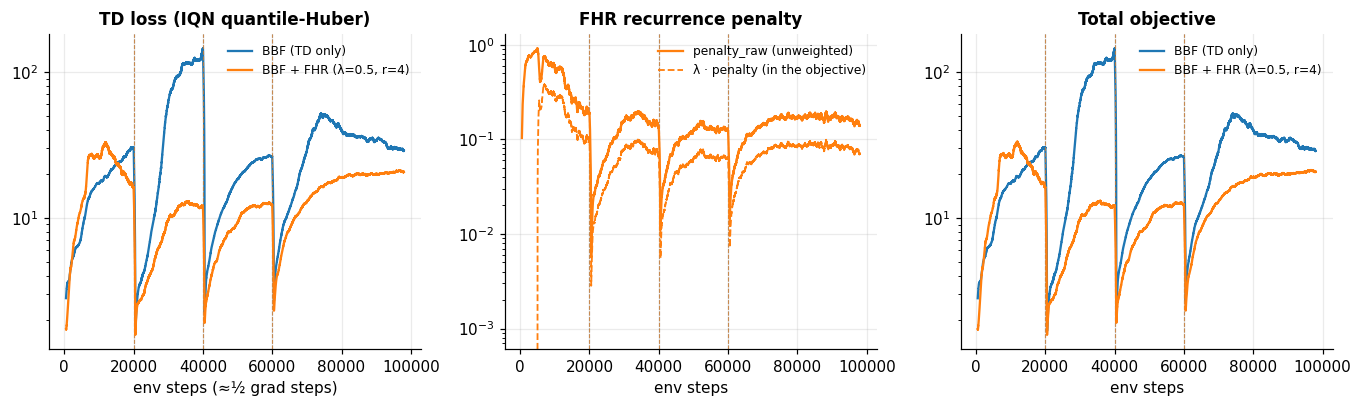

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.8))
K = 500
for name, d in DATA.items():
    g = d["diag"]
    x = np.arange(len(g))[K - 1:]
    axes[0].plot(x, smooth(g["td_loss"], K), lw=1.5, color=d["colour"], label=name)
    lam = g["lambda_eff"]
    pen_w = np.where(np.isnan(g["penalty_raw"]), 0.0, g["penalty_raw"]) * lam
    total = g["td_loss"] + pen_w
    axes[2].plot(x, smooth(total, K), lw=1.5, color=d["colour"], label=name)
    if np.nanmax(lam) > 0:
        axes[1].plot(x, smooth(np.nan_to_num(g["penalty_raw"]), K), lw=1.5,
                     color=d["colour"], label="penalty_raw (unweighted)")
        axes[1].plot(x, smooth(pen_w, K), lw=1.2, ls="--", color=d["colour"],
                     label="λ · penalty (in the objective)")
    for rp in reset_positions(g):
        for a in axes:
            a.axvline(rp, color=d["colour"], ls="--", lw=0.7, alpha=0.4)
axes[0].set(title="TD loss (IQN quantile-Huber)", xlabel="env steps (≈½ grad steps)",
            yscale="log")
axes[1].set(title="FHR recurrence penalty", xlabel="env steps", yscale="log")
axes[2].set(title="Total objective", xlabel="env steps", yscale="log")
for a in axes:
    a.legend(fontsize=8)
plt.tight_layout()

**Reading this:** the FHR arm's TD loss runs higher — the penalty deliberately
constrains the Q-function away from the pure TD optimum, trading raw Bellman fit for
temporal self-consistency. The penalty itself keeps *falling* across training (the
Q-function becomes progressively more recurrence-representable), and the spikes at every
reset — where a re-initialised network briefly breaks the learned recurrence — anneal
away within each cycle.

## 6 · FHR internals — learned recurrence coefficients

final coefficients: c = [1.1, -0.068, 0.017, -0.049]   sum = 1.000


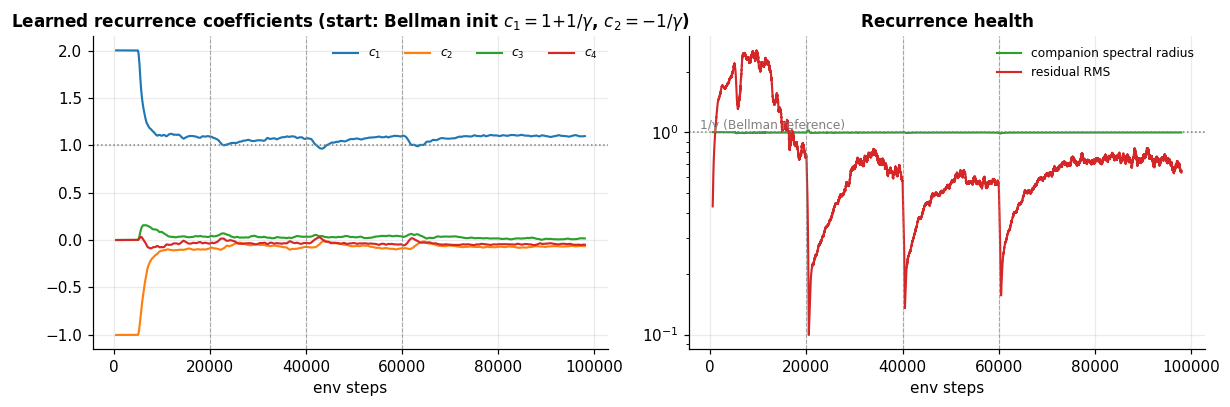

In [7]:
d = DATA["BBF + FHR (λ=0.5, r=4)"]; g = d["diag"]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8))
K = 500
x = np.arange(len(g))[K - 1:]
for j, c in enumerate([f"c_{i}" for i in range(1, 5)]):
    a1.plot(x, smooth(g[c], K), lw=1.4, label=f"$c_{j+1}$")
a1.axhline(1.0, color="gray", ls=":", lw=1)
a1.set(title="Learned recurrence coefficients (start: Bellman init $c_1{=}1{+}1/γ$, $c_2{=}{-}1/γ$)",
       xlabel="env steps")
a1.legend(ncol=4, fontsize=8)
a2.plot(x, smooth(g["companion_radius"], K), lw=1.4, color="tab:green",
        label="companion spectral radius")
a2.plot(x, smooth(g["residual_rms"], K), lw=1.4, color="tab:red",
        label="residual RMS")
a2.axhline(1 / 0.997, color="gray", ls=":", lw=1)
a2.annotate("1/γ (Bellman reference)", (0.02, 1 / 0.997),
            xycoords=("axes fraction", "data"), fontsize=8, color="gray", va="bottom")
for rp in reset_positions(g):
    a1.axvline(rp, color="gray", ls="--", lw=0.7, alpha=0.4)
    a2.axvline(rp, color="gray", ls="--", lw=0.7, alpha=0.4)
a2.set(title="Recurrence health", xlabel="env steps", yscale="log")
a2.legend(fontsize=8)
plt.tight_layout()
print(f"final coefficients: c = {[round(float(g[f'c_{i}'][-1]), 3) for i in range(1, 5)]}"
      f"   sum = {float(g['sum_c'][-1]):.3f}")

## 7 · Schedules and the reset mechanism

**Shrink-and-perturb** (SR-SPR → BBF): every **40,000 gradient steps** (= 20k env steps
at replay ratio 2) the agent is partially re-initialised —

1. a **fresh network** is drawn (Xavier-uniform, as in the reference);
2. the **IQN head** (everything outside the conv encoder) is **fully replaced** by the
   fresh draw; the **encoder** is interpolated **50 % toward** it
   ($\theta \leftarrow 0.5\,\theta + 0.5\,\theta_{\text{fresh}}$);
3. the EMA **target network receives the identical treatment** from its own independent
   draw; Adam moments are zeroed for the replaced head and kept for the encoder;
4. the **n-step (10→3) and γ (0.97→0.997) annealing schedules restart**, re-annealing
   over the next 10k gradient steps;
5. the FHR coefficients $c$ are agent-level parameters and **survive** the reset.

Resets counteract the loss of plasticity that high replay-ratio training causes. Our v1
experiment showed the *final* reset (at 160k gradient steps) never recovered without
SPR/PER as recovery engines, so this recipe stops resetting after 130k gradient steps
(`no_resets_after_grad_steps`) — the one deliberate schedule change from `BBF.gin`.

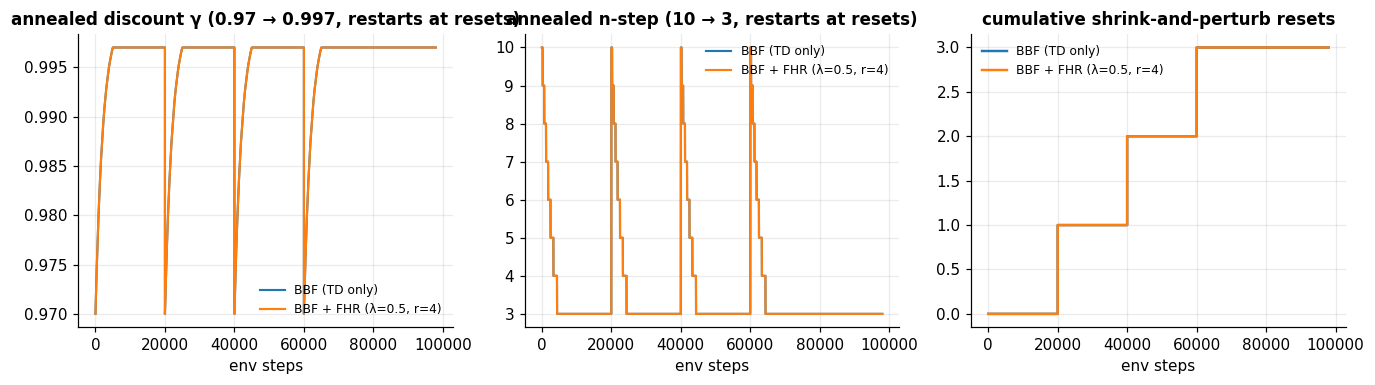

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.6))
for name, d in DATA.items():
    g = d["diag"]
    x = np.arange(len(g))
    axes[0].plot(x, g["gamma_eff"], lw=1.4, color=d["colour"], label=name)
    axes[1].plot(x, g["n_step_eff"], lw=1.4, color=d["colour"], label=name)
    axes[2].step(x, g["resets"], lw=1.6, color=d["colour"], label=name)
axes[0].set(title="annealed discount γ (0.97 → 0.997, restarts at resets)",
            xlabel="env steps")
axes[1].set(title="annealed n-step (10 → 3, restarts at resets)", xlabel="env steps")
axes[2].set(title="cumulative shrink-and-perturb resets", xlabel="env steps")
for a in axes:
    a.legend(fontsize=8)
plt.tight_layout()

## 8 · Low-rank structure of the learned value function

The FHR penalty is a surrogate for a **low Hankel-rank prior** on Q-value sequences along
trajectories (Kronecker: Hankel rank ≤ r ⇔ an order-r linear recurrence). The training
loop probes this directly every ~40 episodes: one greedy rollout, build the Hankel matrix
of the Q (and V) sequence, record its **stable rank** and thresholded effective rank
(`hankel_sweep.csv`). A pre-experiment diagnostic on a trained policy already showed
Krull value sequences are near rank 1–2 with mild higher-order structure (order-4/5 best
at long forecast horizons) — the basis for choosing r = 4.

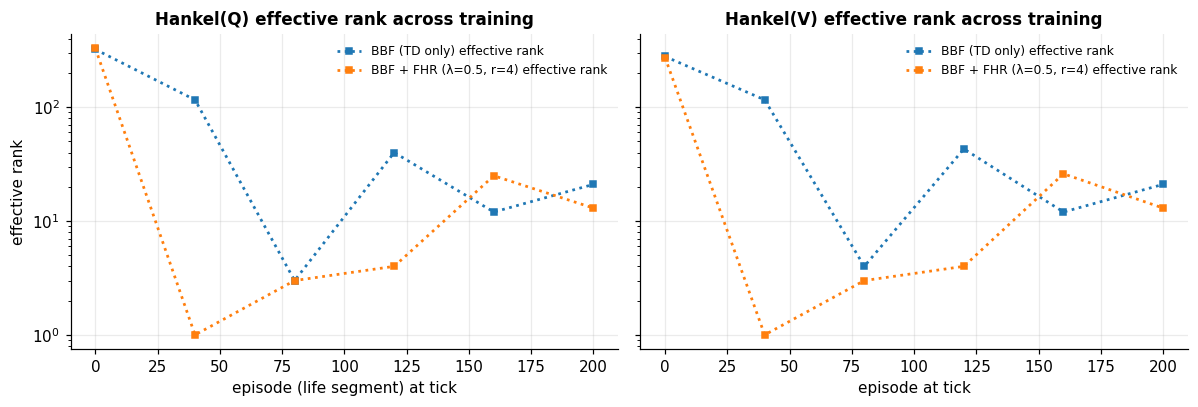

In [9]:
def load_sweep(run):
    rows = list(csv.DictReader(open(HERE / run / "hankel_sweep.csv")))
    out = {}
    for r in rows:
        out.setdefault(r["matrix"], []).append(
            (int(r["episode"]), float(r["eff_rank"]), float(r["stable_rank"]),
             int(r["sub_len"])))
    return out

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for name, d in DATA.items():
    sw = load_sweep(d["dir"])
    for mat, ax in (("Hankel Q", a1), ("Hankel V", a2)):
        pts = sorted(sw.get(mat, []))
        eps = [p[0] for p in pts]
        ax.plot(eps, [p[1] for p in pts], "s:", lw=1.8, ms=4.5,
                color=d["colour"], label=f"{name} effective rank")
a1.set(title="Hankel(Q) effective rank across training",
       xlabel="episode (life segment) at tick", ylabel="effective rank",
       yscale="log")
a2.set(title="Hankel(V) effective rank across training", xlabel="episode at tick",
       yscale="log")
a1.legend(fontsize=8); a2.legend(fontsize=8)
plt.tight_layout()

Both arms collapse from the random-initialisation effective rank (tens to
hundreds) toward low values as the value function organises over training. The
tick-to-tick jitter is expected: the thresholded effective rank counts every singular
value above a fixed fraction, so it is sensitive to rollout length and small trailing
singular values. The regulariser's effect shows up less in the *final* rank than in
**how consistently** the low-rank structure holds (§3's variance collapse, §5's falling
residual).

## 9 · Gameplay — final policies, one full game each (evaluation seed 1000)

Recorded from the final checkpoints under exactly the evaluation protocol (full game,
ε = 0.001; playback ≈4× real time because frames are captured post-frameskip).

In [10]:
from IPython.display import HTML
vids = {n: sorted(glob.glob(str(HERE / "videos" / f"{t}_seed0_score*.mp4")))[-1]
        for n, t in (("BBF (TD only)", "baseline"), ("BBF + FHR (λ=0.5, r=4)", "fhr"))}
html = "<table><tr>"
for name, path in vids.items():
    rel = pathlib.Path(path).relative_to(HERE)
    score = pathlib.Path(path).stem.split("score")[-1]
    html += (f"<td style='text-align:center;padding:0 14px'><b>{name}</b><br>"
             f"<span style='color:gray'>this game: {score} points</span><br>"
             f"<video src='{rel}' controls width='340'></video></td>")
html += "</tr></table>"
HTML(html)

BBF (TD only)this game: 2760 points,"BBF + FHR (λ=0.5, r=4)this game: 3910 points"


## 10 · Conclusions

| arm (seed 0, 32 full-game eval episodes) | mean | median | std | HNS |
|---|---|---|---|---|
| BBF recipe, TD only | 3283 | 2570 | 1857 | 1.58 |
| **BBF + FHR (λ=0.5, r=4)** | **3853** | **3990** | **813** | **2.11** |

1. **The FHR regulariser improves the BBF recipe on Krull**: +17 % mean, +55 % median,
   and — most strikingly — **half the evaluation variance** on paired evaluation
   episodes. The TD-only baseline is erratic (episodes from 520 to 6510); the FHR arm
   plays consistently near its peak.
2. This lands the port **above published SPR (3689) and just below DrQ (4018/4402)** —
   with one seed, RR 2, and *without* SPR or prioritized replay. The TD-only plateau at
   ~3270 across two recipe iterations (with and without the late reset) supports the
   interpretation that the 90M-parameter encoder is **under-constrained by TD alone**,
   and the FHR penalty supplies a useful auxiliary signal in the role SPR plays for
   published BBF.
3. **Caveats**: single seed (tuning phase); λ = 0.5 and r = 4 carried over from the
   EfficientRainbow-era sweeps, not tuned for BBF; published BBF's 8223 (RR 8, +SPR,
   +PER, 50 seeds) remains the ceiling, not the bar.
4. **Next**: seed replication; a λ sweep ({0.05, 0.2, 0.5}); the same ± FHR comparison
   on the EfficientRainbow recipe under this corrected protocol (runs queued in the
   `effrainbow100k` family); and — if chasing published BBF — adding SPR for a
   three-way SPR / FHR / SPR+FHR auxiliary study.

In [11]:
# Cross-recipe status: EfficientRainbow ± FHR under the corrected protocol
mp = HERE / "cached" / "effrainbow100k_runs_manifest.json"
if mp.exists():
    m = json.load(open(mp))
    done = [(arm, seed, json.load(open(HERE / rel / "eval_summary.json")))
            for arm, seeds in m["runs"].items() for seed, rel in seeds.items()
            if (HERE / rel / "eval_summary.json").exists()]
    if done:
        print("EfficientRainbow (fixed protocol) results so far:")
        for arm, seed, s in sorted(done):
            print(f"  {arm:9s} seed {seed}: mean {s['mean']:7.1f}  "
                  f"median {s['median']:7.1f}  HNS {s['hns_mean']:.3f}")
    else:
        print("EfficientRainbow (fixed protocol) runs queued/in progress — "
              "re-run this cell when the phase completes.")

EfficientRainbow (fixed protocol) results so far:
  baseline  seed 0: mean  4766.6  median  4815.0  HNS 2.968
  baseline  seed 1: mean  3657.8  median  3860.0  HNS 1.930
